- hapax_legomena: Number of words that occur only once in the document.
- total_tokens: Total number of word tokens in the document.
- total_terms: Number of unique word types (vocabulary size) in the document.
- vocabulary_density: Ratio of unique words to total words, indicating lexical diversity.
- hapax_dislegomena: Number of words that occur exactly twice in the document.
- char_count: Total number of characters in the document.
- word_count: Total number of words in the document (same as total_tokens).
- unique_word_count: Number of unique words in the document (same as total_terms).
- avg_word_length: Average length of words in the document.
- ttr: Type-token ratio, a measure of lexical diversity.
- hapax_legomenon_rate: Proportion of hapax legomena relative to total tokens.
- DTM: each term is a feature


NOTES:
Overly predicting Madison

In [45]:
# 1) Imports and paths
from pathlib import Path
import pandas as pd
import numpy as np
from lexos.dtm import DTM
from sklearn.svm import SVC
from lexos.classification import trainer
import lexos.corpus.corpus_stats as cs

import seaborn as sns
import matplotlib.pyplot as plt

BASE = Path.cwd()  # run this notebook from doc_src/docs/tutorials/classification
DATA = BASE / "fed_papers"

print("Base:", BASE)
print("Data dir exists:", DATA.exists())


Base: c:\Users\gabal\LocalFiles\Lexos_Independant_Research\lexos\doc_src\docs\tutorials\classification
Data dir exists: True


In [46]:
# 2) Collect train and test files
train_dirs = ["HAMILTON", "MADISON"]
test_dirs = ["COAUTHORED", "DISPUTED"]

train_files = []
for d in train_dirs:
    train_files.extend(sorted((DATA / d).glob("*.txt")))

test_files = []
for d in test_dirs:
    test_files.extend(sorted((DATA / d).glob("*.txt")))

print("Train files:", len(train_files), "Test files:", len(test_files))
assert train_files and test_files, "No files found; check working directory and folder structure."

Train files: 65 Test files: 15


In [47]:
# Ensure consistent ordering of data

all_files = [*train_files, *test_files]

train_files = sorted(train_files, key=lambda x: x.name)  # Sort train files by file name
test_files = sorted(test_files, key=lambda x: x.name)    # Sort test files by file name
all_files = sorted(all_files, key=lambda x: x.name)      # Sort all files by file name

# Verify the order of files
print("Train files (sorted):", [f.name for f in train_files])
print("Test files (sorted):", [f.name for f in test_files])
print("All files (sorted):", [f.name for f in all_files])

Train files (sorted): ['FED_10_M.txt', 'FED_11_H.txt', 'FED_12_H.txt', 'FED_13_H.txt', 'FED_14_M.txt', 'FED_15_H.txt', 'FED_16_H.txt', 'FED_17_H.txt', 'FED_1_H.txt', 'FED_21_H.txt', 'FED_22_H.txt', 'FED_23_H.txt', 'FED_24_H.txt', 'FED_25_H.txt', 'FED_26_H.txt', 'FED_27_H.txt', 'FED_28_H.txt', 'FED_29_H.txt', 'FED_30_H.txt', 'FED_31_H.txt', 'FED_32_H.txt', 'FED_33_H.txt', 'FED_34_H.txt', 'FED_35_H.txt', 'FED_36_H.txt', 'FED_37_M.txt', 'FED_38_M.txt', 'FED_39_M.txt', 'FED_40_M.txt', 'FED_41_M.txt', 'FED_42_M.txt', 'FED_43_M.txt', 'FED_44_M.txt', 'FED_45_M.txt', 'FED_46_M.txt', 'FED_47_M.txt', 'FED_48_M.txt', 'FED_59_H.txt', 'FED_60_H.txt', 'FED_61_H.txt', 'FED_65_H.txt', 'FED_66_H.txt', 'FED_67_H.txt', 'FED_68_H.txt', 'FED_69_H.txt', 'FED_6_H.txt', 'FED_70_H.txt', 'FED_71_H.txt', 'FED_72_H.txt', 'FED_73_H.txt', 'FED_74_H.txt', 'FED_75_H.txt', 'FED_76_H.txt', 'FED_77_H.txt', 'FED_78_H.txt', 'FED_79_H.txt', 'FED_7_H.txt', 'FED_80_H.txt', 'FED_81_H.txt', 'FED_82_H.txt', 'FED_83_H.txt', 'FED

In [48]:
# 3) Scrubber + Tokenizer
from lexos.scrubber.scrubber import Scrubber
from lexos.tokenizer import Tokenizer

scrubber = Scrubber()
scrubber.add_pipe("lower_case")
scrubber.add_pipe("digits")
scrubber.add_pipe("punctuation")

tokenizer = Tokenizer(model="en_core_web_sm")  # or any installed model

In [49]:
# 4) Build docs for CorpusStats (train + test) and collect tokens for DTM
from lexos.corpus.corpus_stats import CorpusStats

docs = []
raw_texts = []
sets_list = []
doc_ids = []  # maintain consistent ordering
tokens_per_doc = []
all_files = [*train_files, *test_files]

for f in all_files:
    raw = f.read_text(encoding="utf-8")
    clean = scrubber.scrub(raw)
    spacy_doc = tokenizer(clean)
    tokens = [t.text for t in spacy_doc if t.text.strip()]
    doc_id = f.name
    # label inside stats is doc_id (stats only)
    docs.append((doc_id, doc_id, tokens))
    raw_texts.append(raw) 
    sets_list.append(f.parent.name)
    doc_ids.append(doc_id)
    tokens_per_doc.append(tokens)

stats = CorpusStats(docs=docs, raw_texts=raw_texts)
stats_df = stats.doc_stats_df.copy()
stats_df.insert(0, "set", sets_list)

display(stats_df.head())
print("Available columns:", list(stats_df.columns))

,set,hapax_legomena,total_tokens,total_terms,vocabulary_density,hapax_dislegomena
Documents,,,,,,
FED_10_M.txt,MADISON,517,3006,846,28.14,137
FED_11_H.txt,HAMILTON,576,2503,835,33.36,106
FED_12_H.txt,HAMILTON,555,2166,787,36.33,106
FED_13_H.txt,HAMILTON,267,967,387,40.02,46
FED_14_M.txt,MADISON,504,2147,748,34.84,127


Available columns: ['set', 'hapax_legomena', 'total_tokens', 'total_terms', 'vocabulary_density', 'hapax_dislegomena']


In [50]:
# 5) Build DTM features from cleaned tokens
dtm = DTM()
dtm(docs=tokens_per_doc, labels=doc_ids, min_df=3)  # raise pruning to reduce rare terms
dtm_df = dtm.to_df(transpose=False)
dtm_df = dtm_df.T
# Optionally keep top-N frequent terms
term_freq = dtm_df.sum(axis=0).sort_values(ascending=False)
keep_terms = term_freq.head(2000).index
dtm_df = dtm_df.loc[:, keep_terms]

print("DTM shape (docs x terms):", dtm_df.shape)
display(dtm_df.iloc[:10, :20])

DTM shape (docs x terms): (80, 2000)


,the,of,to,and,in,a,be,that,it,is,which,by,as,this,not,would,have,will,for,or
FED_10_M.txt,261,157,100,121,63,78,61,31,47,41,39,39,20,11,16,6,16,30,18,22
FED_11_H.txt,188,180,83,70,66,69,44,24,21,9,25,20,21,24,20,50,15,17,18,12
FED_12_H.txt,176,141,82,62,54,47,40,27,26,22,23,15,19,17,10,22,13,11,8,7
FED_13_H.txt,74,58,43,17,14,26,25,18,6,9,11,5,8,5,5,14,4,9,1,3
FED_14_M.txt,202,124,72,60,40,37,45,33,31,25,40,18,24,13,14,5,17,26,20,11
FED_15_H.txt,254,196,117,74,73,69,44,38,30,48,55,32,15,24,18,13,31,19,18,38
FED_16_H.txt,193,143,89,42,39,37,55,16,37,14,22,13,19,18,20,36,12,5,9,17
FED_17_H.txt,162,110,58,52,29,30,24,21,16,11,24,9,3,11,6,12,4,12,11,13
FED_1_H.txt,132,106,72,40,27,25,34,28,20,13,18,14,10,14,15,2,10,25,12,6
FED_21_H.txt,184,151,55,49,48,64,40,24,17,27,20,22,18,17,11,12,9,6,5,21


In [51]:
# 5b) Sanity checks: non-zero variance, NaNs, alignment
print("Stats DF shape:", stats_df.shape)
print("DTM DF shape:", dtm_df.shape)
print("Shared index count:", len(stats_df.index.intersection(dtm_df.index)))

# Check for all-zero or constant columns
def constant_cols(df):
    return [c for c in df.columns if df[c].nunique(dropna=False) <= 1]

zero_var_stats = constant_cols(stats_df.drop(columns=["set"]))
zero_var_terms = constant_cols(dtm_df)

print("Zero/constant stats features:", zero_var_stats[:20])
print("Zero/constant term features count:", len(zero_var_terms))

# Inspect a few documents’ tokens to ensure scrubber/tokenizer working
for i in range(3):
    print(f"Sample doc {i} id:", doc_ids[i], "tokens sample:", tokens_per_doc[i][:20])

# Ensure stats features are numeric and not all zeros
print("Stats feature sample rows:")
display(stats_df.head(3))

# If too few terms due to min_df=2, relax pruning:
# dtm = DTM()
# dtm(docs=tokens_per_doc, labels=doc_ids, min_df=1)  # try 1

Stats DF shape: (80, 6)
DTM DF shape: (80, 2000)
Shared index count: 80
Zero/constant stats features: []
Zero/constant term features count: 0
Sample doc 0 id: FED_10_M.txt tokens sample: ['to', 'the', 'people', 'of', 'the', 'state', 'of', 'new', 'york', 'among', 'the', 'numerous', 'advantages', 'promised', 'by', 'a', 'wellconstructed', 'union', 'none', 'deserves']
Sample doc 1 id: FED_11_H.txt tokens sample: ['to', 'the', 'people', 'of', 'the', 'state', 'of', 'new', 'york', 'the', 'importance', 'of', 'the', 'union', 'in', 'a', 'commercial', 'light', 'is', 'one']
Sample doc 2 id: FED_12_H.txt tokens sample: ['to', 'the', 'people', 'of', 'the', 'state', 'of', 'new', 'york', 'the', 'effects', 'of', 'union', 'upon', 'the', 'commercial', 'prosperity', 'of', 'the', 'states']
Stats feature sample rows:


,set,hapax_legomena,total_tokens,total_terms,vocabulary_density,hapax_dislegomena
Documents,,,,,,
FED_10_M.txt,MADISON,517,3006,846,28.14,137
FED_11_H.txt,HAMILTON,576,2503,835,33.36,106
FED_12_H.txt,HAMILTON,555,2166,787,36.33,106


In [52]:
# 6) Combine stats features with DTM and create train/test splits
import numpy as np
import pandas as pd

# Use all per-document features available from CorpusStats (exclude the helper "set" column)
feature_cols = [c for c in stats_df.columns if c != "set"]

# Align indexes: ensure stats_df and dtm_df share doc_id index
assert all(idx in dtm_df.index for idx in stats_df.index), "DTM and stats indices must align"

stats_features_df = stats_df.loc[:, feature_cols]

# Optional: ensure numeric dtype for all stats features
stats_features_df = stats_features_df.apply(pd.to_numeric, errors="coerce").fillna(0.0)

combined_X_df = pd.concat([stats_features_df, dtm_df], axis=1)
# Drop constant and near-constant columns
non_constant_mask = combined_X_df.apply(lambda col: col.nunique(dropna=False) > 1)
combined_X_df = combined_X_df.loc[:, non_constant_mask]
feature_names = combined_X_df.columns.tolist()

# Train/test masks using the same sets as above
train_mask = stats_df["set"].isin(["HAMILTON", "MADISON"])
test_mask  = stats_df["set"].isin(["COAUTHORED", "DISPUTED"])

X_train = combined_X_df.loc[train_mask].values
y_train = stats_df.loc[train_mask, "set"].values

X_test = combined_X_df.loc[test_mask].values
test_doc_ids = stats_df.loc[test_mask].index
test_sets = stats_df.loc[test_mask, "set"].values

print("Features shape (train/test):", X_train.shape, X_test.shape)
print("Total features (stats + terms):", len(feature_names))
print("Features used in the model:")
print(feature_names)

Features shape (train/test): (65, 2005) (15, 2005)
Total features (stats + terms): 2005
Features used in the model:
['hapax_legomena', 'total_tokens', 'total_terms', 'vocabulary_density', 'hapax_dislegomena', 'the', 'of', 'to', 'and', 'in', 'a', 'be', 'that', 'it', 'is', 'which', 'by', 'as', 'this', 'not', 'would', 'have', 'will', 'for', 'or', 'their', 'from', 'with', 'are', 'an', 'on', 'they', 'states', 'been', 'government', 'may', 'state', 'all', 'but', 'its', 'other', 'power', 'has', 'can', 'people', 'at', 'if', 'more', 'any', 'than', 'them', 'one', 'no', 'constitution', 'there', 'those', 'we', 'must', 'these', 'who', 'upon', 'such', 'i', 'so', 'most', 'his', 'every', 'union', 'same', 'should', 'federal', 'was', 'might', 'against', 'new', 'national', 'under', 'authority', 'were', 'public', 'great', 'into', 'had', 'ought', 'only', 'our', 'some', 'powers', 'shall', 'general', 'executive', 'between', 'time', 'could', 'united', 'less', 'each', 'part', 'what', 'members', 'body', 'number'

In [53]:
# 7) Train lexos Decision Tree via trainer

my_depth = 10

clf = trainer.fit_classifier(
    X_train,
    y_train,
    model="decision_tree",
    random_state=42,
    max_depth=my_depth,
    min_samples_leaf=3,
    min_samples_split=5,
    max_features="sqrt"
)
print("Train accuracy:", clf.score(X_train, y_train))

# Check importance distribution
imp = getattr(clf, "feature_importances_", None)
print("Non-zero importances:", (imp > 0).sum(), "out of", len(imp))

Train accuracy: 0.9076923076923077
Non-zero importances: 7 out of 2005


In [54]:
# Predict on the training set
y_pred_train = clf.predict(X_train)

# Create a DataFrame to compare true labels and predicted labels for the training set
train_comparison_df = pd.DataFrame({
    "Doc ID": stats_df.loc[train_mask].index,  # Use the document IDs for the training set
    "True Label": y_train,
    "Predicted Label": y_pred_train
}).sort_values(["True Label", "Doc ID"])

# Display the comparison table for the training set
display(train_comparison_df)

,Doc ID,True Label,Predicted Label
1,FED_11_H.txt,HAMILTON,HAMILTON
2,FED_12_H.txt,HAMILTON,HAMILTON
3,FED_13_H.txt,HAMILTON,HAMILTON
5,FED_15_H.txt,HAMILTON,HAMILTON
6,FED_16_H.txt,HAMILTON,HAMILTON
...,...,...,...
32,FED_44_M.txt,MADISON,HAMILTON
33,FED_45_M.txt,MADISON,MADISON
34,FED_46_M.txt,MADISON,MADISON
35,FED_47_M.txt,MADISON,HAMILTON


In [55]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring="accuracy")
print("CV accuracy (mean ± std):", cv_scores.mean(), cv_scores.std())

CV accuracy (mean ± std): 0.7384615384615385 0.07844645405527362


,feature,importance
267,community,0.284478
1470,although,0.229981
409,according,0.209900
23,for,0.175032
366,distinct,0.043918
106,he,0.029615
605,expedient,0.027077
3,vocabulary_density,0.000000
4,hapax_dislegomena,0.000000
1973,contemplate,0.000000


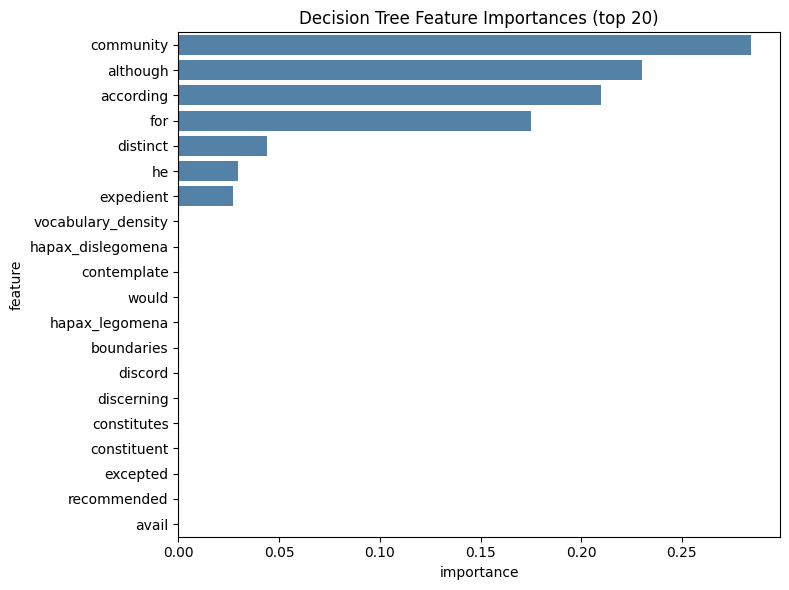

In [56]:
# 8) Feature importances (top-N for readability)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

imp = getattr(clf, "feature_importances_", None)
if imp is None:
    raise RuntimeError("Model does not provide feature_importances_.")

imp_df = pd.DataFrame({"feature": feature_names, "importance": imp})
imp_df = imp_df.sort_values("importance", ascending=False)

top_n = 20
top_imp_df = imp_df.head(top_n)
display(imp_df.head(30))

plt.figure(figsize=(8, 6))
sns.barplot(data=top_imp_df, x="importance", y="feature", color="steelblue")
plt.title(f"Decision Tree Feature Importances (top {top_n})")
plt.tight_layout()
plt.show()

,feature,perm_mean,perm_std
409,according,0.110769,0.017039
1470,although,0.096410,0.031008
23,for,0.091282,0.022093
267,community,0.086154,0.029620
3,vocabulary_density,0.000000,0.000000
4,hapax_dislegomena,0.000000,0.000000
1973,contemplate,0.000000,0.000000
20,would,0.000000,0.000000
0,hapax_legomena,0.000000,0.000000
1990,boundaries,0.000000,0.000000


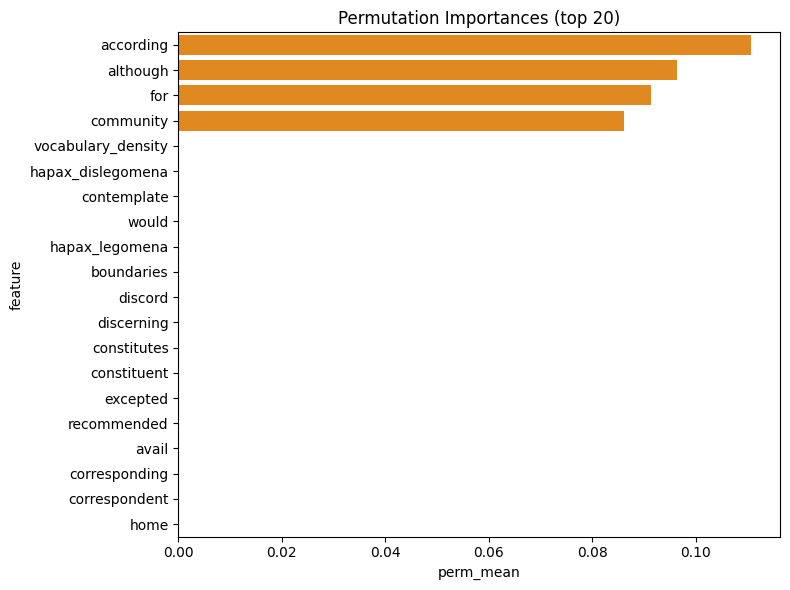

In [57]:
# 9) Permutation importance on training set
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    clf,
    X_train,
    y_train,
    n_repeats=15,
    random_state=42,
    scoring="accuracy",
)

perm_df = pd.DataFrame({
    "feature": feature_names,
    "perm_mean": perm.importances_mean,
    "perm_std": perm.importances_std
}).sort_values("perm_mean", ascending=False)

display(perm_df.head(30))

plt.figure(figsize=(8, 6))
sns.barplot(data=perm_df.head(20), x="perm_mean", y="feature", color="darkorange")
plt.title("Permutation Importances (top 20)")
plt.tight_layout()
plt.show()

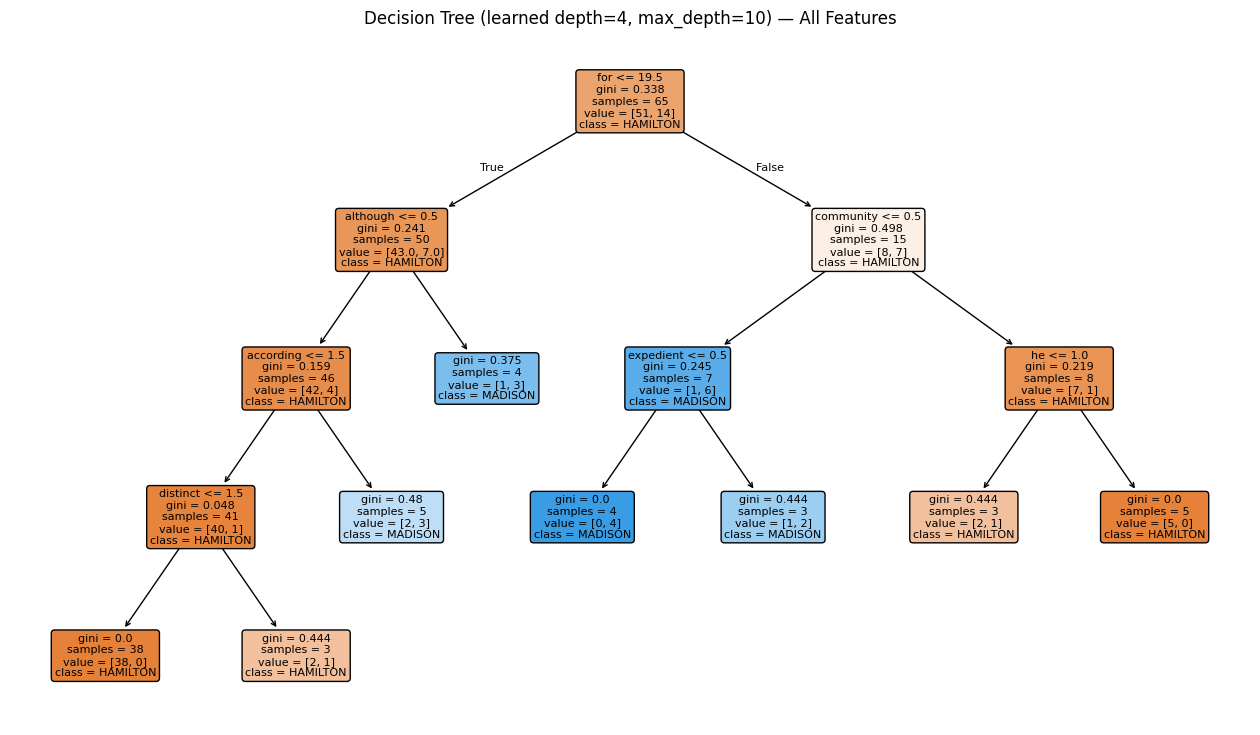

In [58]:
# 10) Visualize the tree
from sklearn.tree import plot_tree
plt.figure(figsize=(16, 9))
plot_tree(
    clf,
    feature_names=feature_names,
    class_names=sorted(set(y_train)),
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title(f"Decision Tree (learned depth={clf.get_depth()}, max_depth={my_depth}) — All Features")
plt.show()

In [59]:
# 11) Predict on COAUTHORED / DISPUTED
y_pred_test = clf.predict(X_test)

pred_df = pd.DataFrame({
    "doc_id": test_doc_ids,
    "set": test_sets,
    "pred_author": y_pred_test
}).sort_values(["set", "doc_id"])

display(pred_df)
print("\nPrediction counts by set:")
print(pred_df.groupby(["set", "pred_author"]).size())

,doc_id,set,pred_author
0,FED_18_C.txt,COAUTHORED,MADISON
1,FED_19_C.txt,COAUTHORED,HAMILTON
2,FED_20_C.txt,COAUTHORED,HAMILTON
3,FED_49_D.txt,DISPUTED,HAMILTON
4,FED_50_D.txt,DISPUTED,MADISON
5,FED_51_D.txt,DISPUTED,HAMILTON
6,FED_52_D.txt,DISPUTED,HAMILTON
7,FED_53_D.txt,DISPUTED,MADISON
8,FED_54_D.txt,DISPUTED,MADISON
9,FED_55_D.txt,DISPUTED,MADISON



Prediction counts by set:
set         pred_author
COAUTHORED  HAMILTON       2
            MADISON        1
DISPUTED    HAMILTON       7
            MADISON        5
dtype: int64
